In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [4]:
df["Country"] = "nigeria"

In [5]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

In [6]:
df["Month"] = df["date"].dt.month

In [7]:
df = df.replace(-999, np.nan)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


In [11]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
date           0.0
Month          0.0
dtype: float64

In [13]:
missing_percent[missing_percent > 5]

Series([], dtype: float64)

In [14]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)
outliers_count = outliers.sum()

outliers_count

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64

In [15]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

In [16]:
df= df.ffill()
df = df.dropna()

In [17]:
df.to_csv("../data/nigeria_clean.csv", index=False)

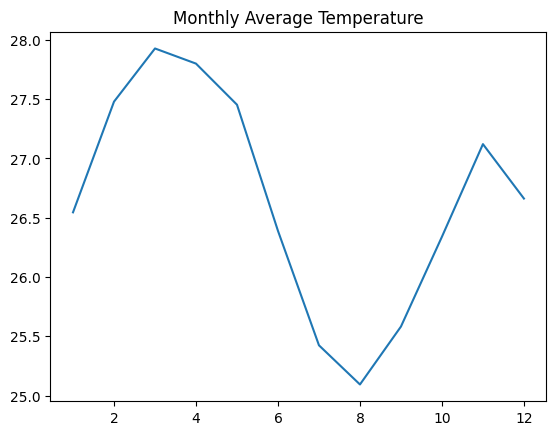

In [18]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature")
plt.show()

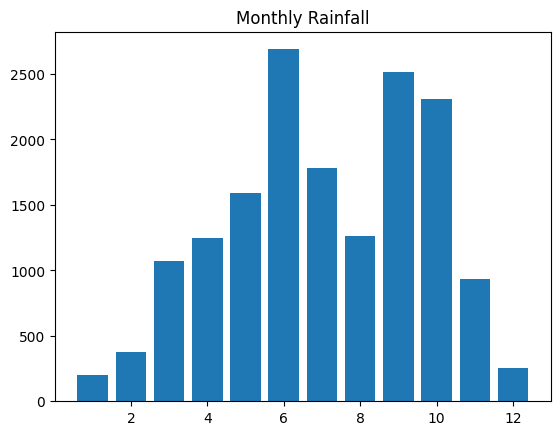

In [19]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.show()

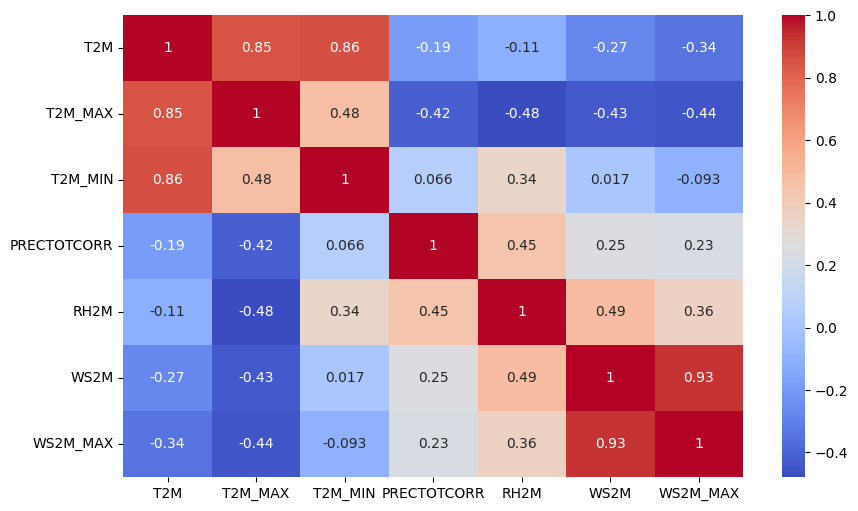

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

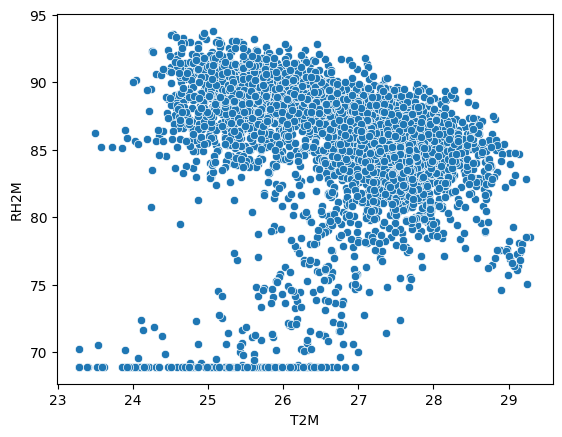

In [21]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

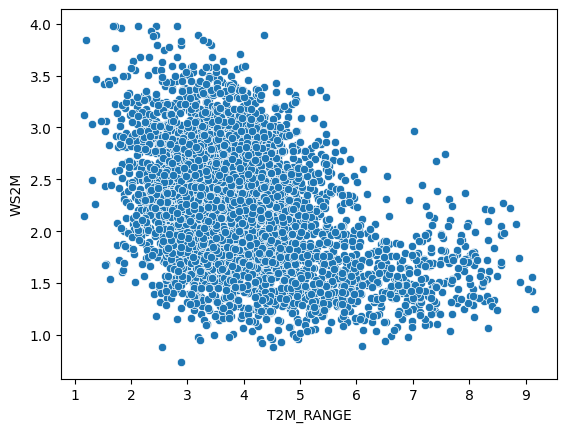

In [22]:
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

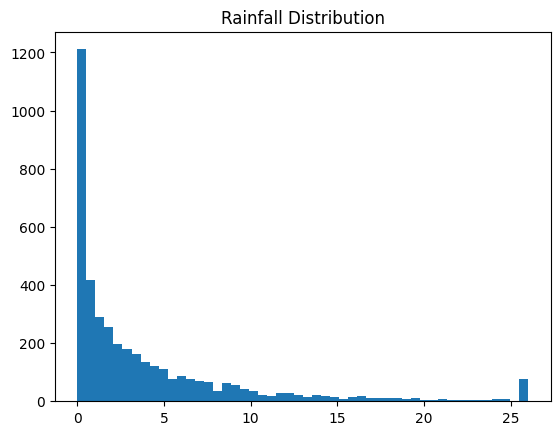

In [23]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

# Climate KPI Report 

##  Temperature Trends
The **Monthly Average Temperature** plot shows a distinctive seasonal fluctuation characteristic of a tropical or subtropical region:
* **Peak Period:** The highest temperatures are reached early in the year, peaking in **March (Month 3)** at approximately **27.9°C**.
* **The Cooling Phase:** Temperatures drop steadily through the second quarter, reaching an annual low in **August (Month 8)** at roughly **25.1°C**.
* **Year-End Recovery:** There is a secondary, smaller peak in **November (Month 11)** (~27.1°C) before a slight cooling toward December.

##  Rainfall Patterns
The **Monthly Rainfall** bar chart reveals a classic monsoon or heavy wet-season pattern:
* **The Surge:** Precipitation begins to rise sharply in March, reaching a primary peak in **June (Month 6)** with over **2,500 units**.
* **Secondary Peak:** After a brief dip in August, rainfall surges again in **September (Month 9)**.
* **Dry Season:** The end and beginning of the year (December through February) are significantly drier, with the lowest levels recorded in January.
* **Distribution:** The **Rainfall Distribution** histogram shows a "long-tail" effect. While most days have low rainfall (0–5 units), there is a notable frequency of extreme weather events shown by the outlier spike at the **25-unit** mark.

##  Strongest Correlations
The **Correlation Heatmap** identifies several critical relationships between variables:
* **Wind Speed Synchronization:** The strongest positive correlation in the entire dataset is between **WS2M (Wind Speed)** and **WS2M_MAX** (**0.93**). This indicates that the average wind speed is an excellent predictor of peak gusts.
* **Temperature Drivers:** Average temperature (**T2M**) is very strongly driven by both maximum (**0.85**) and minimum (**0.86**) temperatures, showing a balanced influence between day and night heat.
* **Humidity & Rainfall:** Relative humidity (**RH2M**) shows a moderate positive correlation with precipitation (**0.45**), confirming that moisture levels rise predictably during the wet months.

## Anomalies and Insights
* **Temperature and Humidity Divergence:** The scatter plot for **RH2M vs. T2M** shows a negative trend. This suggests that as the average temperature increases, relative humidity tends to decrease, likely because the hottest months (March/April) precede the peak moisture months (June/September).
* **Wind vs. Temperature Range:** Interestingly, the scatter plot for **WS2M vs. T2M_RANGE** shows a negative correlation. Higher wind speeds are associated with a *smaller* temperature range. This suggests that wind helps mix the air, preventing extreme daytime heating and nighttime cooling.

---
**Summary Statement:** > *“Temperature and humidity show a negative correlation in this region, meaning the hottest months are often the driest. The climate is defined by a heavy monsoon period peaking in June, which significantly lowers the average temperature through cloud cover and evaporation.”*